In [1]:
!apt-get update -qq
!apt-get install -y -qq libvips42

!pip uninstall -y transformers
!pip install -q "transformers==4.51.1" accelerate einops pillow pandas tqdm pyvips bitsandbytes qwen-vl-utils

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Preconfiguring packages ...
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../systemd-sysv_249.11-0ubuntu3.20_amd64.deb ...
Unpacking systemd-sysv (249.11-0ubuntu3.20) over (249.11-0ubuntu3.19) ...
Preparing to unpack .../libpam-systemd_249.11-0ubuntu3.20_amd64.deb ...
Unpacking libpam-systemd:amd64 (249.11-0ubuntu3.20) over (249.11-0ubuntu3.19) ...
Preparing to unpack .../systemd_249.11-0ubuntu3.20_amd64.deb ...
Unpacking systemd (249.11-0ubuntu3.20) over (249.11-0ubuntu3.19) ...
Preparing to unpack .../libsystemd0_249.11-0ubuntu3.20_amd64.deb ...
Unpacking libsystemd0:amd64 (249.11-0ubuntu3.20) over (249.11-0ubuntu3.19) ...
Setting up libsystemd0:amd64 (249.11-0ubuntu3.20) ...
Selecting previously unselected pac

In [2]:
import os
import gc
import json
import torch
import pandas as pd

from PIL import Image
from tqdm import tqdm
from google.colab import drive

drive.mount("/content/drive")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Mounted at /content/drive
Device: cuda


In [8]:
BASE = "/content/drive/MyDrive/Tattoo-YOLO"
SPLIT = "train"

IMAGE_DIR = os.path.join(BASE, SPLIT, "images")

OUT_DIR = os.path.join(BASE, SPLIT, "vlm_comparison_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

JSON_OUT = os.path.join(OUT_DIR, "comparison_results.json")
CSV_OUT = os.path.join(OUT_DIR, "comparison_results.csv")

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")

In [9]:
def list_images(image_dir):
    return sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith(IMG_EXTENSIONS)
    ])

def load_image(path):
    return Image.open(path).convert("RGB")

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [10]:
QUESTIONS = {
    "scene_description": (
        "Briefly describe the visible body region and the general scene. "
        "Do not invent details that are not visible."
    ),

    "has_tattoo": (
        "Is there any visible tattoo in the image? "
        "Answer only: yes, no, or uncertain."
    ),

    "tattoo_count": (
        "How many visible tattoos are there? "
        "Answer with a number if possible, otherwise say uncertain."
    ),

    "tattoo_location": (
        "If there is a visible tattoo, where is it located on the body? "
        "Choose the closest option: arm, forearm, hand, chest, abdomen, back, shoulder, neck, leg, foot, multiple locations, other, uncertain."
    ),

    "tattoo_size": (
        "What is the approximate visible size of the tattoo relative to the visible body area? "
        "Choose one: small, medium, large, uncertain."
    ),

    "tattoo_color": (
        "Does the tattoo contain visible colors, or does it appear black/gray only? "
        "Answer only: colored, black/gray, uncertain."
    ),

    "tattoo_style": (
        "What is the visual style of the tattoo? "
        "Choose one: line-art, filled/solid, shaded, realistic, text-only, simple symbol, complex illustration, uncertain."
    ),

    "tattoo_category": (
        "What is the main type of tattoo motif? "
        "Choose one: animal, person/face, text/lettering, symbol, object, plant/flower, geometric, abstract, fantasy/creature, other, uncertain."
    ),

    "tattoo_motif_description": (
        "Briefly describe the visible tattoo motif. "
        "If unclear, answer uncertain. Do not guess."
    ),

    "contains_text": (
        "Does the tattoo contain readable text or lettering? "
        "Answer only: yes, no, or uncertain."
    ),

    "text_content": (
        "If readable text is visible in the tattoo, transcribe it exactly. "
        "If none or unclear, answer none or uncertain."
    ),

    "visual_complexity": (
        "How visually complex is the tattoo? "
        "Choose one: simple, moderate, complex, uncertain."
    ),

    "confidence": (
        "How confident are you in your tattoo assessment? "
        "Choose one: low, medium, high."
    )
}

Total images: 3090
Selected image: 102350_jpg.rf.17ec79292f68e03741c9483e67a5f734.jpg


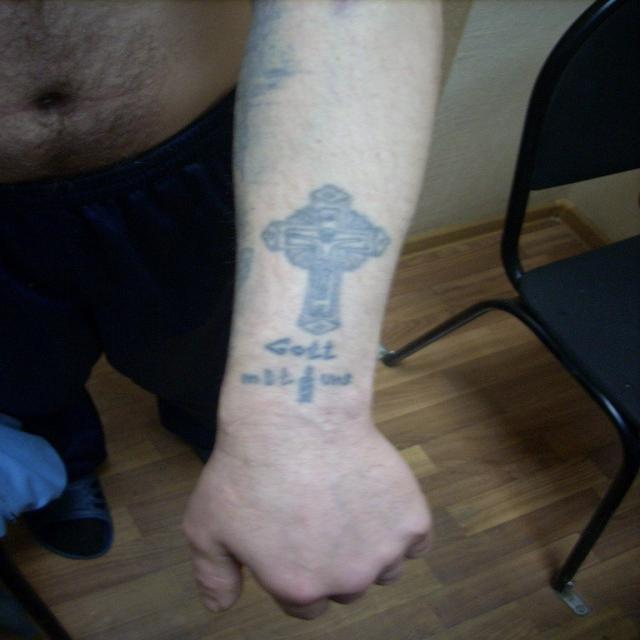

In [35]:
image_paths = list_images(IMAGE_DIR)

print("Total images:", len(image_paths))

INDEX = 33  # cambia este índice

image_path = image_paths[INDEX]
image = load_image(image_path)

print("Selected image:", os.path.basename(image_path))
display(image)

Modelo 1 - Moondream2

In [24]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MOONDREAM_ID = "vikhyatk/moondream2"
MOONDREAM_REVISION = "2025-01-09"

moondream_model = AutoModelForCausalLM.from_pretrained(
    MOONDREAM_ID,
    revision=MOONDREAM_REVISION,
    trust_remote_code=True,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

moondream_tokenizer = AutoTokenizer.from_pretrained(
    MOONDREAM_ID,
    revision=MOONDREAM_REVISION,
    trust_remote_code=True
)

print("Moondream2 cargado")

Moondream2 cargado


In [36]:
def ask_moondream(image, question):
    with torch.no_grad():
        encoded_image = moondream_model.encode_image(image)
        answer = moondream_model.answer_question(
            encoded_image,
            question,
            moondream_tokenizer
        )
    return answer.strip()

moondream_answers = {}

for key, question in tqdm(QUESTIONS.items()):
    try:
        moondream_answers[key] = ask_moondream(image, question)
    except Exception as e:
        moondream_answers[key] = f"ERROR: {str(e)}"

moondream_answers

100%|██████████| 13/13 [00:12<00:00,  1.06it/s]


{'scene_description': 'The image shows a person\'s forearm with a tattoo of a cross and the words "Gott" and "m\'ll go out" underneath. The person is standing in a room with a wooden floor and a black chair.',
 'has_tattoo': 'yes',
 'tattoo_count': '2',
 'tattoo_location': 'arm',
 'tattoo_size': 'medium',
 'tattoo_color': 'colored, black/gray, uncertain',
 'tattoo_style': 'text-only',
 'tattoo_category': 'symbol',
 'tattoo_motif_description': 'A cross with a face inside it',
 'contains_text': 'yes',
 'text_content': 'Gotti in the out',
 'visual_complexity': 'complex',
 'confidence': 'medium'}

In [14]:
del moondream_model
del moondream_tokenizer
clean_memory()

print("Moondream2 liberado")

Moondream2 liberado


Modelo 2 - Llava

In [26]:
from transformers import LlavaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

LLAVA_ID = "llava-hf/llava-1.5-7b-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

llava_model = LlavaForConditionalGeneration.from_pretrained(
    LLAVA_ID,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
)

llava_processor = AutoProcessor.from_pretrained(LLAVA_ID)

print("LLaVA cargado")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

LLaVA cargado


In [37]:
def ask_llava(image, question):
    prompt = f"USER: <image>\n{question}\nASSISTANT:"

    inputs = llava_processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = llava_model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False
        )

    decoded = llava_processor.batch_decode(
        output,
        skip_special_tokens=True
    )[0]

    if "ASSISTANT:" in decoded:
        decoded = decoded.split("ASSISTANT:")[-1]

    return decoded.strip()

llava_answers = {}

for key, question in tqdm(QUESTIONS.items()):
    try:
        llava_answers[key] = ask_llava(image, question)
    except Exception as e:
        llava_answers[key] = f"ERROR: {str(e)}"

llava_answers

100%|██████████| 13/13 [00:20<00:00,  1.60s/it]


{'scene_description': "The visible body region is a man's arm with a tattoo on it. The general scene is a room with a chair and a dining table. The man is standing next to the table, and his arm is visible with the tattoo.",
 'has_tattoo': 'Yes',
 'tattoo_count': '1',
 'tattoo_location': 'Arm',
 'tattoo_size': 'Small',
 'tattoo_color': 'The tattoo appears to be black/gray, but it is also described as having visible colors.',
 'tattoo_style': 'Fill/solid',
 'tattoo_category': 'Text/Lettering',
 'tattoo_motif_description': 'The visible tattoo motif is a cross.',
 'contains_text': 'Yes',
 'text_content': 'The tattoo on the man\'s arm reads "God with us."',
 'visual_complexity': 'Complex',
 'confidence': 'Medium'}

In [17]:
del llava_model
del llava_processor
clean_memory()

print("LLaVA liberado")

LLaVA liberado


Modelo 3 - Qwen

In [18]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

QWEN_ID = "Qwen/Qwen2-VL-2B-Instruct"

qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_ID,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto"
)

qwen_processor = AutoProcessor.from_pretrained(QWEN_ID)

print("Qwen2-VL cargado")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Qwen2-VL cargado


In [38]:
def ask_qwen(image_path, question):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": question}
            ]
        }
    ]

    text = qwen_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = qwen_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = qwen_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text.strip()

qwen_answers = {}

for key, question in tqdm(QUESTIONS.items()):
    try:
        qwen_answers[key] = ask_qwen(image_path, question)
    except Exception as e:
        qwen_answers[key] = f"ERROR: {str(e)}"

qwen_answers

  0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
100%|██████████| 13/13 [00:14<00:00,  1.13s/it]


{'scene_description': 'The image shows a person\'s arm with a tattoo of a cross and the word "Gott" written underneath it. The tattoo is on the inner forearm, and the person is standing next to a chair. The background includes a wooden floor and a wall with a light-colored texture.',
 'has_tattoo': 'Yes.',
 'tattoo_count': '2',
 'tattoo_location': 'The tattoo is located on the arm.',
 'tattoo_size': 'large',
 'tattoo_color': 'The tattoo appears to be black and gray only.',
 'tattoo_style': 'The tattoo on the person\'s arm appears to be a combination of line art and text. The cross is depicted with a simple, linear design, while the word "Gott mit uns" is written in a more complex, filled style. Therefore, the visual style of the tattoo can be described as:\n\n- Text-only',
 'tattoo_category': 'The main type of tattoo motif on the arm is a symbol.',
 'tattoo_motif_description': 'The visible tattoo motif on the person\'s arm is a cross with the word "Gott" (God) written underneath it.',


In [39]:
comparison_rows = []

for key, question in QUESTIONS.items():
    comparison_rows.append({
        "question_key": key,
        "question": question,
        "moondream2": moondream_answers.get(key),
        "llava_1_5_7b": llava_answers.get(key),
        "qwen2_vl_2b": qwen_answers.get(key)
    })

comparison_df = pd.DataFrame(comparison_rows)

pd.set_option("display.max_colwidth", 300)
comparison_df

,question_key,question,moondream2,llava_1_5_7b,qwen2_vl_2b
0,scene_description,Briefly describe the visible body region and the general scene. Do not invent details that are not visible.,"The image shows a person's forearm with a tattoo of a cross and the words ""Gott"" and ""m'll go out"" underneath. The person is standing in a room with a wooden floor and a black chair.","The visible body region is a man's arm with a tattoo on it. The general scene is a room with a chair and a dining table. The man is standing next to the table, and his arm is visible with the tattoo.","The image shows a person's arm with a tattoo of a cross and the word ""Gott"" written underneath it. The tattoo is on the inner forearm, and the person is standing next to a chair. The background includes a wooden floor and a wall with a light-colored texture."
1,has_tattoo,"Is there any visible tattoo in the image? Answer only: yes, no, or uncertain.",yes,Yes,Yes.
2,tattoo_count,"How many visible tattoos are there? Answer with a number if possible, otherwise say uncertain.",2,1,2
3,tattoo_location,"If there is a visible tattoo, where is it located on the body? Choose the closest option: arm, forearm, hand, chest, abdomen, back, shoulder, neck, leg, foot, multiple locations, other, uncertain.",arm,Arm,The tattoo is located on the arm.
4,tattoo_size,"What is the approximate visible size of the tattoo relative to the visible body area? Choose one: small, medium, large, uncertain.",medium,Small,large
5,tattoo_color,"Does the tattoo contain visible colors, or does it appear black/gray only? Answer only: colored, black/gray, uncertain.","colored, black/gray, uncertain","The tattoo appears to be black/gray, but it is also described as having visible colors.",The tattoo appears to be black and gray only.
6,tattoo_style,"What is the visual style of the tattoo? Choose one: line-art, filled/solid, shaded, realistic, text-only, simple symbol, complex illustration, uncertain.",text-only,Fill/solid,"The tattoo on the person's arm appears to be a combination of line art and text. The cross is depicted with a simple, linear design, while the word ""Gott mit uns"" is written in a more complex, filled style. Therefore, the visual style of the tattoo can be described as:\n\n- Text-only"
7,tattoo_category,"What is the main type of tattoo motif? Choose one: animal, person/face, text/lettering, symbol, object, plant/flower, geometric, abstract, fantasy/creature, other, uncertain.",symbol,Text/Lettering,The main type of tattoo motif on the arm is a symbol.
8,tattoo_motif_description,"Briefly describe the visible tattoo motif. If unclear, answer uncertain. Do not guess.",A cross with a face inside it,The visible tattoo motif is a cross.,"The visible tattoo motif on the person's arm is a cross with the word ""Gott"" (God) written underneath it."
9,contains_text,"Does the tattoo contain readable text or lettering? Answer only: yes, no, or uncertain.",yes,Yes,yes


En tatuajes muy claros los 3 funcionan bien pero en casos con texto o tatuajes más complejos el mejor modelo es Qwen.